# Predictive Maintenance — Preprocessing & Feature Engineering
This notebook runs the full preprocessing and feature engineering pipeline on the CMAPSS FD001 dataset and visualises the results at each stage.

## 0. Imports

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Allow imports from src/data
sys.path.append('../src/data')

from preprocessing import process_data
from feature_engineering import feature_engineering

sns.set_theme(style='darkgrid')
%matplotlib inline

## 1. Run Preprocessing Pipeline

In [12]:
process_data(
    test_file='../data/raw/test_FD001.txt',
    train_file='../data/raw/train_FD001.txt',
    RUL_file='../data/raw/RUL_FD001.txt',
    train_dir='../data/processed/train_FD001_processed.csv',
    test_dir='../data/processed/test_FD001_processed.csv'
)

train_df = pd.read_csv('../data/processed/train_FD001_processed.csv')
test_df  = pd.read_csv('../data/processed/test_FD001_processed.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Dropping 7 low-variance sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1       -0.0007       -0.0004         100.0   
1            1               2        0.0019       -0.0003         100.0   
2            1               3       -0.0043        0.0003         100.0   
3            1               4        0.0007        0.0000         100.0   
4            1               5       -0.0019       -0.0002         100.0   

   sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  \
0    641.82   1589.70   1400.60    554.36   2388.06   9046.19      47.47   
1    642.15   1591.82   1403.14    553.75   2388.04   9044.07      47.49   
2    642.35   1587.99   1404.20    554.26   2388.08   9052.94      47.27   
3    642.35   1582.79   1401.87    554.45   2388.11   9049.48      47.13   
4    642.37   1582.85   1406.22    554.00

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


## 2. Verify RUL Labels

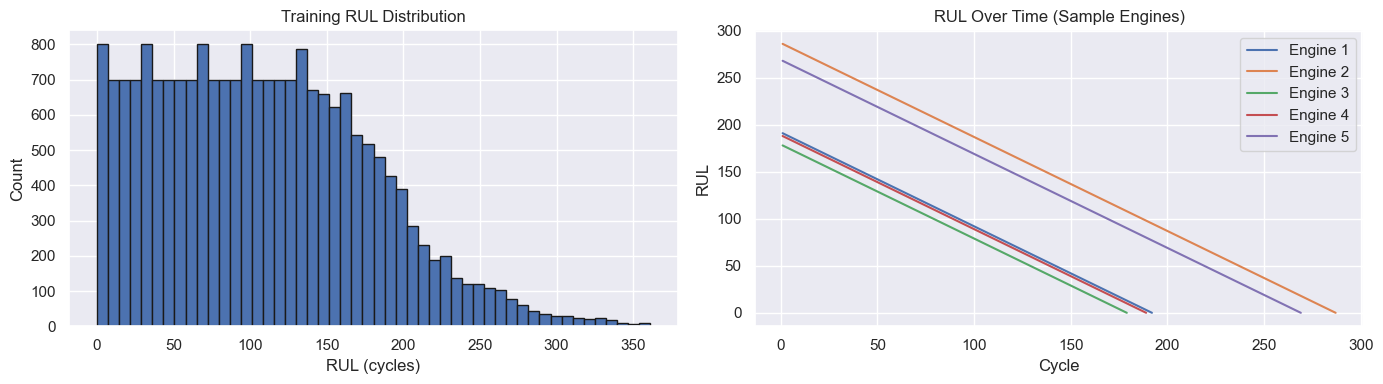

In [13]:
# Check RUL distribution across training set
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['RUL'], bins=50, edgecolor='k')
axes[0].set_title('Training RUL Distribution')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')

# Show RUL curve for a few sample engines
sample_units = [1, 2, 3, 4, 5]
for unit in sample_units:
    subset = train_df[train_df['unit_number'] == unit]
    axes[1].plot(subset['time_in_cycles'], subset['RUL'], label=f'Engine {unit}')

axes[1].set_title('RUL Over Time (Sample Engines)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('RUL')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Inspect Sensor Variance (before drop)

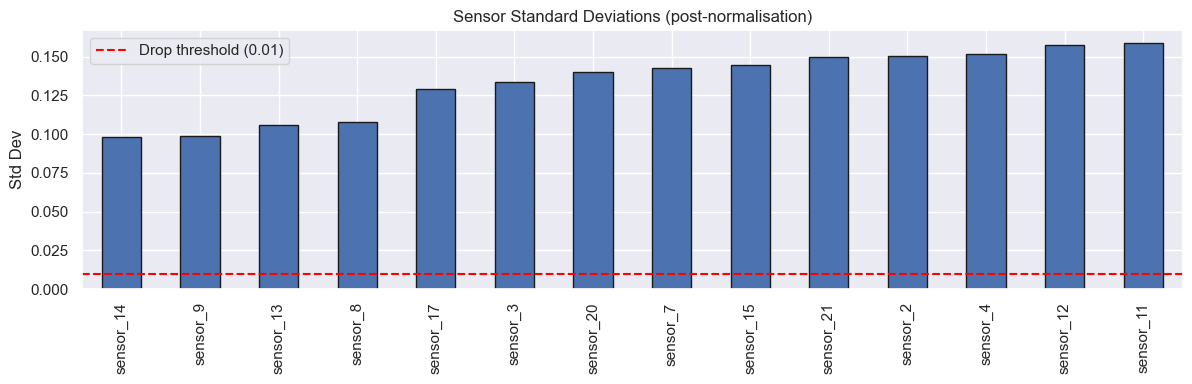

Sensors remaining: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [14]:
# Show which sensors survived the low-variance drop
sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]

stds = train_df[sensor_cols].std().sort_values()

plt.figure(figsize=(12, 4))
stds.plot(kind='bar', edgecolor='k')
plt.axhline(y=0.01, color='red', linestyle='--', label='Drop threshold (0.01)')
plt.title('Sensor Standard Deviations (post-normalisation)')
plt.ylabel('Std Dev')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Sensors remaining: {sensor_cols}')

## 4. Sensor Correlation Heatmap

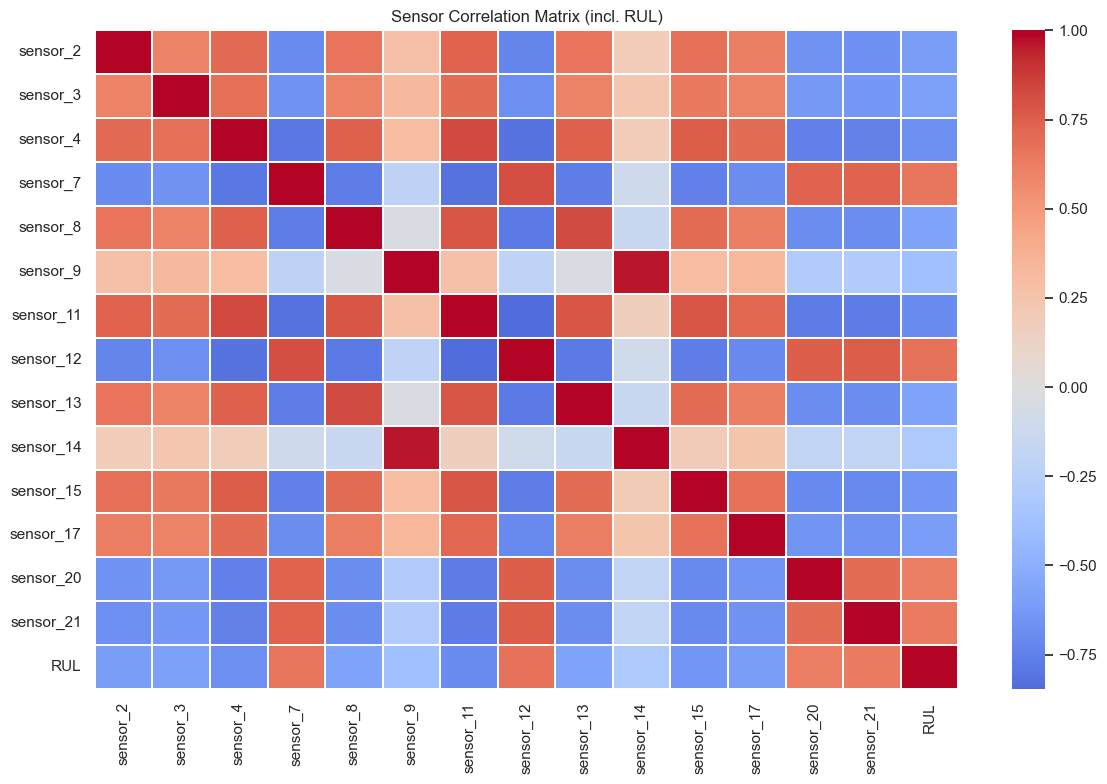

In [15]:
corr_cols = sensor_cols + ['RUL']
corr = train_df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Sensor Correlation Matrix (incl. RUL)')
plt.tight_layout()
plt.show()

## 5. Run Feature Engineering Pipeline

In [16]:
train_fe, test_fe = feature_engineering(train_df.copy(), test_df.copy())

train_fe.to_csv('../data/processed/train_FD001_features.csv', index=False)
test_fe.to_csv('../data/processed/test_FD001_features.csv', index=False)

print('Train shape after FE:', train_fe.shape)
print('Test shape after FE: ', test_fe.shape)
train_fe.head()

Train shape after FE: (20431, 92)
Test shape after FE:  (12896, 92)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_20_rolling_mean,sensor_20_rolling_std,sensor_20_lag1,sensor_20_lag2,sensor_20_delta,sensor_21_rolling_mean,sensor_21_rolling_std,sensor_21_lag1,sensor_21_lag2,sensor_21_delta
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,...,0.669251,0.042694,0.666667,0.713178,-0.038760,0.692350,0.061548,0.731014,0.724662,-0.109638
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,...,0.645349,0.059164,0.627907,0.666667,-0.054264,0.684859,0.052440,0.621375,0.731014,0.041011
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,...,0.634109,0.057070,0.573643,0.627907,0.015504,0.688788,0.046256,0.662386,0.621375,0.042115
5,1,6,0.252874,0.416667,0.0,0.268072,0.292784,0.272113,0.776167,0.181818,...,0.621705,0.039679,0.589147,0.573643,0.062016,0.674399,0.043408,0.704502,0.662386,-0.051781
6,1,7,0.557471,0.583333,0.0,0.382530,0.463920,0.261985,0.723027,0.181818,...,0.637209,0.067223,0.651163,0.589147,0.093023,0.661640,0.029873,0.652720,0.704502,0.014499


## 6. Visualise Rolling Features vs Raw Signal

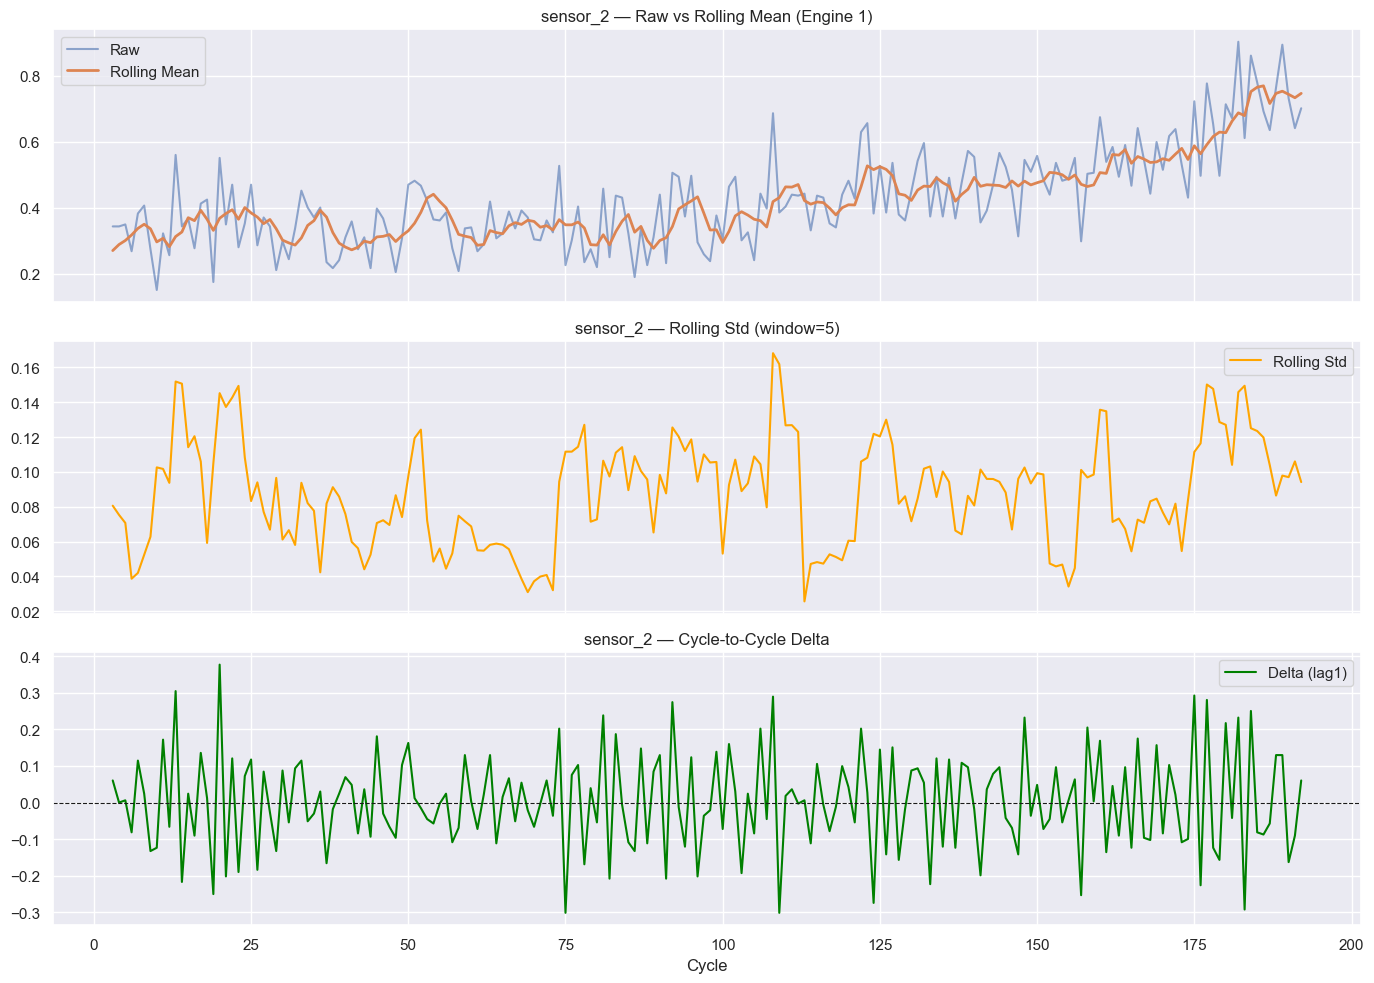

In [17]:
# Pick one engine and one sensor to compare raw vs smoothed
UNIT   = 1
SENSOR = 'sensor_2'   # one of the strongest degradation signals in FD001

subset = train_fe[train_fe['unit_number'] == UNIT]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(subset['time_in_cycles'], subset[SENSOR], alpha=0.6, label='Raw')
axes[0].plot(subset['time_in_cycles'], subset[SENSOR + '_rolling_mean'], label='Rolling Mean', linewidth=2)
axes[0].set_title(f'{SENSOR} — Raw vs Rolling Mean (Engine {UNIT})')
axes[0].legend()

axes[1].plot(subset['time_in_cycles'], subset[SENSOR + '_rolling_std'], color='orange', label='Rolling Std')
axes[1].set_title(f'{SENSOR} — Rolling Std (window={5})')
axes[1].legend()

axes[2].plot(subset['time_in_cycles'], subset[SENSOR + '_delta'], color='green', label='Delta (lag1)')
axes[2].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[2].set_title(f'{SENSOR} — Cycle-to-Cycle Delta')
axes[2].set_xlabel('Cycle')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Operational Clusters

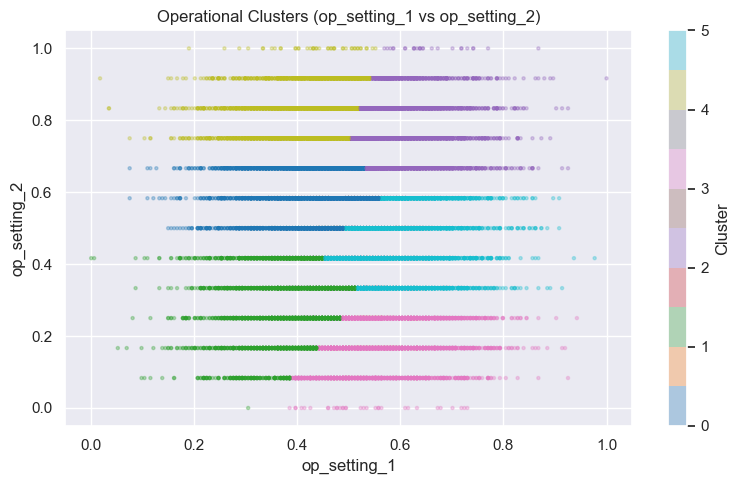

In [18]:
# FD001 has one operating condition so clusters should be tight
# This plot confirms the cluster assignments make sense
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    train_fe['op_setting_1'],
    train_fe['op_setting_2'],
    c=train_fe['op_cluster'],
    cmap='tab10',
    alpha=0.3,
    s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('Operational Clusters (op_setting_1 vs op_setting_2)')
plt.xlabel('op_setting_1')
plt.ylabel('op_setting_2')
plt.tight_layout()
plt.show()

## 8. Feature Summary

In [19]:
feature_cols = [col for col in train_fe.columns if col not in ['unit_number', 'time_in_cycles', 'RUL']]

print(f'Total features going into modelling: {len(feature_cols)}')
print('\nFeature groups:')
print(f" Raw sensors: {len([c for c in feature_cols if c.startswith('sensor_') and '_' not in c.replace('sensor_','',1)])}")
print(f" Rolling means: {len([c for c in feature_cols if '_rolling_mean' in c])}")
print(f" Rolling stds: {len([c for c in feature_cols if '_rolling_std' in c])}")
print(f" Lag 1: {len([c for c in feature_cols if '_lag1' in c])}")
print(f" Lag 2: {len([c for c in feature_cols if '_lag2' in c])}")
print(f" Deltas: {len([c for c in feature_cols if '_delta' in c])}")
print(f" Other (cluster, cycle_norm, op_settings): {len([c for c in feature_cols if not c.startswith('sensor_')])}")

Total features going into modelling: 89

Feature groups:
 Raw sensors: 14
 Rolling means: 14
 Rolling stds: 14
 Lag 1: 14
 Lag 2: 14
 Deltas: 14
 Other (cluster, cycle_norm, op_settings): 5
